# NB-04C — Backtest de cartera técnica V4 pre-FinBERT

**Objetivo del notebook**  
Convertir las señales técnicas V4 ya auditadas en una simulación de cartera con capital limitado, partiendo de un capital inicial de **200.000 USD**.
Pregunta a responder:
> Si tengo 200.000 USD y aplico las señales técnicas V4 con reglas de gestión Core50/Táctico50, ¿cuánto gana o pierde la cartera en USD y en %?

## Contexto metodológico

1. En los notebooks anteriores se validó primero el módulo técnico sobre un universo reducido de 40 tickers. Ese universo estaba sesgado hacia grandes ganadores estructurales, por lo que el buy & hold equal-weight resultaba muy competitivo o superior en retorno absoluto.
2. A partir de ese hallazgo se amplió la muestra a prácticamente todo el S&P 500 para probar el filtro técnico en una muestra más heterogénea.
3. El 04B V4 generó señales con contrato Ichimoku más estricto: precio sobre Kumo, Kumo actual y futuro alcista, dos Heiken Ashi alcistas, cruce estocástico alcista, volumen y liquidez.
4. El 04B2 V4 auditó esas señales una por una con la lógica Core50/Táctico50.
5. Este 04C transforma esa auditoría individual en una cartera ejecutable con restricciones de capital, máximo de posiciones y no duplicación simultánea por ticker.

## Importante

Este sigue siendo un backtest **técnico puro**. Todavía no se incorpora FinBERT ni XGBoost. La capa FinBERT se evaluará después como veto/contexto, especialmente sobre años problemáticos como 2022.

In [1]:
# ============================================================
# 0. Setup
# ============================================================

import os
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RUN_TIMESTAMP = datetime.now().isoformat(timespec='seconds')

INITIAL_CAPITAL = 200_000.0
COST_BPS = 10
SLIPPAGE_BPS = 5
BASE_MAX_POSITIONS = 20
MAX_POSITIONS_GRID = [10, 20, 30]

OUTPUT_DIR = Path('outputs_nb04c_portfolio_v4_pre_finbert')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Run timestamp:', RUN_TIMESTAMP)
print('Output dir:', OUTPUT_DIR.resolve())

Run timestamp: 2026-05-20T13:31:16
Output dir: /Users/rbr/TFM_MVP/outputs_nb04c_portfolio_v4_pre_finbert


In [2]:
# ============================================================
# 1. Localización robusta de archivos de entrada
# ============================================================

SEARCH_DIRS = [
    Path.cwd(),
    Path('/mnt/data'),
    Path('/Users/rbr/TFM_MVP'),
    Path('/Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c'),
    Path('/Users/rbr/TFM_MVP/outputs_nb04b_screener_ha2_stoch_kumo_actual_bullish_contract_v4'),
]

REQUIRED_FILE = 'df_nb04b2_v4_signal_trade_audit.csv'
OPTIONAL_SUMMARY = 'summary_nb04b2_v4.json'


def find_file(filename, search_dirs=SEARCH_DIRS):
    candidates = []
    for base in search_dirs:
        try:
            p = base / filename
            if p.exists():
                candidates.append(p)
        except Exception:
            pass
    if candidates:
        return candidates[0]
    for base in [Path.cwd(), Path('/mnt/data')]:
        if base.exists():
            found = list(base.rglob(filename))
            if found:
                return found[0]
    raise FileNotFoundError(f'No se encontró {filename}. Coloca el archivo en el directorio del notebook o ajusta SEARCH_DIRS.')

trade_audit_path = find_file(REQUIRED_FILE)
print('Archivo de auditoría de señales encontrado:')
print(trade_audit_path)

try:
    summary_path = find_file(OPTIONAL_SUMMARY)
    with open(summary_path, 'r', encoding='utf-8') as f:
        summary_b2 = json.load(f)
    print()
    print('Summary NB04B2 V4 encontrado:')
    print(summary_path)
except Exception:
    summary_b2 = {}
    print()
    print('Summary opcional no encontrado. Continuamos solo con el CSV de auditoría.')

Archivo de auditoría de señales encontrado:
/Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/df_nb04b2_v4_signal_trade_audit.csv

Summary NB04B2 V4 encontrado:
/Users/rbr/TFM_MVP/outputs_nb04b2_signal_audit_v4_pre04c/summary_nb04b2_v4.json


In [3]:
# ============================================================
# 2. Carga y validación del dataset de señales auditadas
# ============================================================

DATE_COLS = [
    'signal_date', 'entry_date', 'tactical_exit_date', 'core_exit_date',
    'trailing_activated_date', 'first_inside_kumo_date', 'first_below_kumo_date',
    'first_stoch_bearish_date', 'first_ha2_bearish_date'
]

header_cols = pd.read_csv(trade_audit_path, nrows=0).columns.tolist()
existing_date_cols = [c for c in DATE_COLS if c in header_cols]

df = pd.read_csv(trade_audit_path, parse_dates=existing_date_cols)

print('Shape:', df.shape)
print('Rango de señales:', df['entry_date'].min(), '→', df['entry_date'].max())
print('Tickers únicos:', df['Ticker'].nunique())
print('Señales:', len(df))

required_cols = [
    'signal_id','Ticker','entry_date','entry_price','tactical_exit_date','tactical_exit_price',
    'core_exit_date','core_exit_price','ret_combo','mfe','mae','entry_family',
    'tk_confirmation_status','chikou_diagnostic_status','technical_priority_score',
    'kumo_actual_thickness_pct','Volume_Rel'
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f'Faltan columnas requeridas: {missing}'
assert df['signal_id'].is_unique, 'signal_id no es único.'
assert (df['entry_price'] > 0).all(), 'Hay entry_price <= 0.'
assert (df['tactical_exit_price'] > 0).all(), 'Hay tactical_exit_price <= 0.'
assert (df['core_exit_price'] > 0).all(), 'Hay core_exit_price <= 0.'
assert df['entry_date'].dt.year.max() <= 2025, 'Hay señales posteriores a 2025.'

print()
print('Validaciones básicas OK.')
display(df.head(5))

Shape: (8155, 38)
Rango de señales: 2018-04-16 00:00:00 → 2025-12-22 00:00:00
Tickers únicos: 502
Señales: 8155

Validaciones básicas OK.


,signal_id,Ticker,Year,signal_date,entry_date,entry_price,entry_execution_mode,entry_family,tk_confirmation_status,chikou_diagnostic_status,technical_priority_score,kumo_actual_thickness_pct,Volume_Rel,Stoch_K_entry,Stoch_D_entry,tactical_exit_date,tactical_exit_price,tactical_exit_reason,core_exit_date,core_exit_price,core_exit_reason,trailing_activated,trailing_activated_date,first_inside_kumo_date,first_below_kumo_date,first_stoch_bearish_date,first_ha2_bearish_date,ret_tactical,ret_core,ret_combo,mfe,mae,mfe_minus_abs_mae,duration_core_bars,duration_tactical_bars,max_high_until_core_exit,min_low_until_core_exit,negative_diagnosis
0,1,ALLE,2018,2018-04-16,2018-04-16,77.3274,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_parcial_sobre_close_22ago,11.2500,0.0255,1.0127,70.7483,64.1724,2018-04-26,71.1861,TACTICAL_EXIT_WITH_CORE_INVALIDATION,2018-04-26,71.1861,CORE_CLOSE_BELOW_KUMO_BOTTOM,False,NaT,2018-04-20,2018-04-26,2018-04-19,2018-04-20,-0.0794,-0.0794,-0.0794,0.0196,-0.1156,-0.0961,8,8,78.8400,68.3872,fallo_sin_recorrido_mfe_menor_2pct
1,2,BF-B,2018,2018-04-16,2018-04-16,48.7357,close_signal,v4_kumo_actual_y_futuro_alcista_tk_maduro,tk_mature_above_kijun_no_recent_cross,chikou_libre_sobre_precio_y_kumo_22ago,10.5000,0.0182,1.2991,92.9632,88.9731,2018-05-25,50.3857,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-06,45.8747,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-05-23,NaT,2018-06-06,2018-04-17,2018-04-19,0.0339,-0.0587,-0.0124,0.0658,-0.0682,-0.0024,36,29,51.9440,45.4113,tuvo_mfe_5pct_y_trailing_pero_combo_negativo
2,3,PGR,2018,2018-04-16,2018-04-16,48.0361,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_no_confirmado_o_sin_historia,8.7500,0.0311,1.4822,62.8572,47.5003,2018-06-18,48.8087,TACTICAL_TRAILING_3PCT_gap_open_below_stop,2018-06-25,47.4448,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-18,2018-04-25,2018-06-25,2018-04-18,2018-04-20,0.0161,-0.0123,0.0019,0.0630,-0.0463,0.0167,49,44,51.0635,45.8129,positive_or_flat
3,4,TECH,2018,2018-04-16,2018-04-16,35.9652,close_signal,v4_kumo_actual_y_futuro_alcista_sin_tk_confirmado,no_tk_confirmation_yet,chikou_libre_sobre_precio_y_kumo_22ago,9.7500,0.0305,1.0450,78.7651,72.5172,2018-06-21,38.8970,TACTICAL_TRAILING_3PCT_stop_intraday,2018-06-27,35.1287,CORE_CLOSE_BELOW_KUMO_BOTTOM,True,2018-06-21,2018-05-03,2018-06-27,2018-04-19,2018-04-30,0.0815,-0.0233,0.0291,0.1150,-0.0430,0.0720,51,47,40.1000,34.4204,positive_or_flat
4,5,TKO,2018,2018-04-16,2018-04-16,35.8697,close_signal,v4_kumo_actual_y_futuro_alcista_con_tk_cross,tk_cross_up_recent,chikou_libre_sobre_precio_y_kumo_22ago,11.5000,0.0604,1.4770,98.3573,92.1879,2018-08-08,72.0430,TACTICAL_EXIT_AT_CORE_OR_MAX_HOLD,2018-08-08,72.0430,MAX_HOLD_OR_DATA_END,False,NaT,NaT,NaT,2018-04-17,2018-06-01,1.0085,1.0085,1.0085,1.1808,-0.0304,1.1504,80,80,78.2242,34.7794,positive_or_flat


## 3. Definición de variantes de cartera

Se comparan variantes incrementales. La idea no es asumir que todas las señales V4 deben ejecutarse con la misma prioridad, sino observar qué ocurre cuando el screener se convierte en decisiones de cartera con capital limitado.

| Variante | Descripción |
|---|---|
| A_V4_COMPLETO | Usa todas las señales V4 elegibles. Selección cronológica determinista cuando hay exceso de señales. |
| B_V4_RANKING | Usa todas las señales V4, pero cuando compiten por capital prioriza ranking técnico/contextual. |
| C_V4_PREFERRED_POOL | Exige TK confirmado, Chikou libre o parcial, Kumo actual al menos mediano y volumen relativo ≥ 1,2. |
| D_V4_HIGH_CONVICTION | Exige Chikou libre, Kumo actual en el 40% superior de grosor y volumen relativo > 1,5. |
| E_V4_HIGH_CONVICTION_TK | Variante D + TK confirmado. Se incluye como sensibilidad adicional. |

La variante D replica la hipótesis operativa derivada del 04B2: las mejores señales no solo cumplen el contrato de entrada, sino que además combinan Chikou despejado, Kumo con mayor grosor y volumen relativo alto.

In [4]:
# ============================================================
# 3. Features derivadas, ranking y variantes
# ============================================================

q50_kumo = df['kumo_actual_thickness_pct'].quantile(0.50)
q60_kumo = df['kumo_actual_thickness_pct'].quantile(0.60)
q75_kumo = df['kumo_actual_thickness_pct'].quantile(0.75)

df = df.copy()
df['chikou_libre'] = df['chikou_diagnostic_status'].astype(str).str.contains('chikou_libre', na=False)
df['chikou_parcial'] = df['chikou_diagnostic_status'].astype(str).str.contains('chikou_parcial', na=False)
df['tk_confirmed'] = ~df['tk_confirmation_status'].astype(str).str.contains('no_tk', na=False)
df['tk_cross_recent'] = df['tk_confirmation_status'].astype(str).str.contains('cross_up_recent', na=False)
df['kumo_q50_or_more'] = df['kumo_actual_thickness_pct'] >= q50_kumo
df['kumo_q60_or_more'] = df['kumo_actual_thickness_pct'] >= q60_kumo
df['kumo_q75_or_more'] = df['kumo_actual_thickness_pct'] >= q75_kumo
df['vol_gt_1_2'] = df['Volume_Rel'] >= 1.2
df['vol_gt_1_5'] = df['Volume_Rel'] > 1.5

# Ranking operativo para resolver competencia por capital en el mismo día.
# No es XGBoost. Es un ranking técnico heurístico, trazable y temporalmente no supervisado.
df['rank_score'] = df['technical_priority_score'].fillna(0).astype(float)
df['rank_score'] += np.where(df['chikou_libre'], 2.0, np.where(df['chikou_parcial'], 0.75, 0.0))
df['rank_score'] += np.where(df['tk_cross_recent'], 1.0, np.where(df['tk_confirmed'], 0.5, 0.0))
df['rank_score'] += np.where(df['kumo_q60_or_more'], 1.0, 0.0)
df['rank_score'] += np.where(df['vol_gt_1_5'], 1.0, np.where(df['vol_gt_1_2'], 0.4, 0.0))

variant_masks = {
    'A_V4_COMPLETO': pd.Series(True, index=df.index),
    'B_V4_RANKING': pd.Series(True, index=df.index),
    'C_V4_PREFERRED_POOL': df['tk_confirmed'] & (df['chikou_libre'] | df['chikou_parcial']) & df['kumo_q50_or_more'] & df['vol_gt_1_2'],
    'D_V4_HIGH_CONVICTION': df['chikou_libre'] & df['kumo_q60_or_more'] & df['vol_gt_1_5'],
    'E_V4_HIGH_CONVICTION_TK': df['chikou_libre'] & df['kumo_q60_or_more'] & df['vol_gt_1_5'] & df['tk_confirmed'],
}

variant_defs = []
for name, mask in variant_masks.items():
    subset = df[mask]
    variant_defs.append({
        'variant': name,
        'eligible_signals': len(subset),
        'eligible_tickers': subset['Ticker'].nunique(),
        'ret_combo_mean_signal_level': subset['ret_combo'].mean(),
        'ret_combo_median_signal_level': subset['ret_combo'].median(),
        'signal_win_rate': (subset['ret_combo'] > 0).mean(),
        'mfe_mean': subset['mfe'].mean(),
        'mae_mean': subset['mae'].mean(),
    })

variant_defs_df = pd.DataFrame(variant_defs)
display(variant_defs_df)
print('Kumo thickness q50:', q50_kumo)
print('Kumo thickness q60:', q60_kumo)
print('Kumo thickness q75:', q75_kumo)

,variant,eligible_signals,eligible_tickers,ret_combo_mean_signal_level,ret_combo_median_signal_level,signal_win_rate,mfe_mean,mae_mean
0,A_V4_COMPLETO,8155,502,0.0153,-0.0000,0.4998,0.1283,-0.0634
1,B_V4_RANKING,8155,502,0.0153,-0.0000,0.4998,0.1283,-0.0634
2,C_V4_PREFERRED_POOL,1960,465,0.0271,0.0073,0.5296,0.1586,-0.0698
3,D_V4_HIGH_CONVICTION,713,331,0.0404,0.0160,0.5722,0.1878,-0.0703
4,E_V4_HIGH_CONVICTION_TK,659,316,0.0396,0.0160,0.5766,0.1870,-0.0711


Kumo thickness q50: 0.0282719413496481
Kumo thickness q60: 0.03415015187002264
Kumo thickness q75: 0.04572605022352045


## 4. Motor de simulación de cartera

### Reglas de simulación

- Capital inicial: 200.000 USD.
- Máximo de posiciones simultáneas configurable.
- No se permite abrir una nueva posición en un ticker si ya existe una posición abierta en ese mismo ticker.
- Cada operación seleccionada se divide en 50% core y 50% táctico.
- Las fechas y precios de salida core/táctica proceden de la auditoría NB-04B2 V4.
- Se incorporan costes y slippage por entrada y salida.
- Cuando varias señales compiten por capital el mismo día, la variante ranking prioriza `rank_score`.
- La curva de equity es **event-driven**: se actualiza en fechas de entradas y salidas. El drawdown se interpreta como drawdown sobre equity basada en coste/realización; el drawdown mark-to-market diario puede añadirse en una versión posterior usando precios diarios completos.

In [5]:
# ============================================================
# 4. Funciones de simulación y métricas
# ============================================================


def simulate_portfolio(
    signals: pd.DataFrame,
    variant: str,
    use_ranking: bool = True,
    max_positions: int = 20,
    initial_capital: float = 200_000.0,
    cost_bps: float = 10,
    slippage_bps: float = 5,
    min_required_cash: float = 1_000.0,
):
    sig = signals.copy()
    sig = sig.dropna(subset=[
        'entry_date','entry_price','tactical_exit_date','tactical_exit_price','core_exit_date','core_exit_price'
    ])

    cost_rate = (cost_bps + slippage_bps) / 10_000

    all_dates = sorted(pd.unique(pd.concat([
        sig['entry_date'], sig['tactical_exit_date'], sig['core_exit_date']
    ]).dropna()))

    entries_by_date = {}
    for d_, g in sig.groupby('entry_date'):
        if use_ranking:
            entries_by_date[pd.Timestamp(d_)] = g.sort_values(
                ['rank_score','technical_priority_score','signal_id'], ascending=[False, False, True]
            )
        else:
            entries_by_date[pd.Timestamp(d_)] = g.sort_values(['signal_id'])

    cash = float(initial_capital)
    active = {}
    trade_rows = []
    equity_rows = []
    skipped_rows = []
    action_rows = []

    for current_date in all_dates:
        current_date = pd.Timestamp(current_date)

        # 1) Procesar salidas primero: libera capital para señales del mismo día.
        for sid, pos in list(active.items()):
            row = pos['row']

            if pos.get('tactical_open', False) and pd.Timestamp(row['tactical_exit_date']) == current_date:
                proceeds = pos['tactical_alloc'] * (row['tactical_exit_price'] / pos['entry_price']) * (1 - cost_rate)
                pnl = proceeds - pos['tactical_alloc']
                cash += proceeds
                pos['tactical_open'] = False
                action_rows.append({
                    'variant': variant, 'date': current_date, 'signal_id': sid, 'Ticker': pos['Ticker'],
                    'action': 'TACTICAL_EXIT', 'cash_after': cash, 'proceeds': proceeds, 'pnl': pnl,
                    'reason': row['tactical_exit_reason']
                })

            if pos.get('core_open', False) and pd.Timestamp(row['core_exit_date']) == current_date:
                proceeds = pos['core_alloc'] * (row['core_exit_price'] / pos['entry_price']) * (1 - cost_rate)
                pnl = proceeds - pos['core_alloc']
                cash += proceeds
                pos['core_open'] = False
                action_rows.append({
                    'variant': variant, 'date': current_date, 'signal_id': sid, 'Ticker': pos['Ticker'],
                    'action': 'CORE_EXIT', 'cash_after': cash, 'proceeds': proceeds, 'pnl': pnl,
                    'reason': row['core_exit_reason']
                })

            if (not pos.get('tactical_open', False)) and (not pos.get('core_open', False)):
                allocation = pos['allocation']
                entry_cost = allocation * cost_rate
                tactical_proceeds = pos['tactical_alloc'] * (row['tactical_exit_price'] / pos['entry_price']) * (1 - cost_rate)
                core_proceeds = pos['core_alloc'] * (row['core_exit_price'] / pos['entry_price']) * (1 - cost_rate)
                pnl_total = tactical_proceeds + core_proceeds - allocation - entry_cost
                ret_net = pnl_total / (allocation + entry_cost)

                trade_rows.append({
                    'variant': variant,
                    'signal_id': sid,
                    'Ticker': pos['Ticker'],
                    'entry_date': pos['entry_date'],
                    'entry_price': pos['entry_price'],
                    'allocation': allocation,
                    'entry_cost': entry_cost,
                    'tactical_exit_date': row['tactical_exit_date'],
                    'core_exit_date': row['core_exit_date'],
                    'tactical_exit_reason': row.get('tactical_exit_reason', None),
                    'core_exit_reason': row.get('core_exit_reason', None),
                    'pnl_usd': pnl_total,
                    'ret_net': ret_net,
                    'ret_combo_original': row['ret_combo'],
                    'rank_score': row['rank_score'],
                    'entry_family': row['entry_family'],
                    'tk_confirmation_status': row['tk_confirmation_status'],
                    'chikou_diagnostic_status': row['chikou_diagnostic_status'],
                    'kumo_actual_thickness_pct': row['kumo_actual_thickness_pct'],
                    'Volume_Rel': row['Volume_Rel'],
                    'mfe': row['mfe'],
                    'mae': row['mae'],
                })
                del active[sid]

        # 2) Procesar entradas del día.
        day_entries = entries_by_date.get(current_date)
        if day_entries is not None:
            for _, row in day_entries.iterrows():
                sid = int(row['signal_id'])

                if sid in active:
                    continue

                if any(pos['Ticker'] == row['Ticker'] for pos in active.values()):
                    skipped_rows.append({
                        'variant': variant, 'date': current_date, 'signal_id': sid,
                        'Ticker': row['Ticker'], 'reason': 'SKIP_TICKER_ALREADY_OPEN'
                    })
                    continue

                if len(active) >= max_positions:
                    skipped_rows.append({
                        'variant': variant, 'date': current_date, 'signal_id': sid,
                        'Ticker': row['Ticker'], 'reason': 'SKIP_MAX_POSITIONS'
                    })
                    continue

                open_cost = sum(
                    (pos['core_alloc'] if pos.get('core_open', False) else 0.0) +
                    (pos['tactical_alloc'] if pos.get('tactical_open', False) else 0.0)
                    for pos in active.values()
                )
                equity_basis = cash + open_cost
                target_allocation = equity_basis / max_positions
                required_cash = target_allocation * (1 + cost_rate)

                if cash < max(min_required_cash, required_cash):
                    skipped_rows.append({
                        'variant': variant, 'date': current_date, 'signal_id': sid,
                        'Ticker': row['Ticker'], 'reason': 'SKIP_INSUFFICIENT_CASH'
                    })
                    continue

                cash -= required_cash
                active[sid] = {
                    'row': row,
                    'Ticker': row['Ticker'],
                    'entry_date': row['entry_date'],
                    'entry_price': row['entry_price'],
                    'allocation': target_allocation,
                    'core_alloc': target_allocation * 0.5,
                    'tactical_alloc': target_allocation * 0.5,
                    'core_open': True,
                    'tactical_open': True,
                }

                action_rows.append({
                    'variant': variant, 'date': current_date, 'signal_id': sid, 'Ticker': row['Ticker'],
                    'action': 'ENTRY', 'cash_after': cash, 'proceeds': -required_cash,
                    'pnl': -target_allocation * cost_rate, 'reason': 'ENTRY_SELECTED'
                })

        # 3) Registrar equity del evento.
        open_cost = sum(
            (pos['core_alloc'] if pos.get('core_open', False) else 0.0) +
            (pos['tactical_alloc'] if pos.get('tactical_open', False) else 0.0)
            for pos in active.values()
        )
        equity = cash + open_cost
        equity_rows.append({
            'variant': variant,
            'date': current_date,
            'cash': cash,
            'open_cost_basis': open_cost,
            'equity_event': equity,
            'n_open_positions': len(active),
            'exposure_cost_pct': open_cost / equity if equity else np.nan,
        })

    eq = pd.DataFrame(equity_rows)
    trades = pd.DataFrame(trade_rows)
    skipped = pd.DataFrame(skipped_rows)
    actions = pd.DataFrame(action_rows)

    if not eq.empty:
        eq['date'] = pd.to_datetime(eq['date'])
        eq['peak'] = eq['equity_event'].cummax()
        eq['drawdown'] = eq['equity_event'] / eq['peak'] - 1

    return eq, trades, skipped, actions


def compute_metrics(eq: pd.DataFrame, trades: pd.DataFrame, variant: str, max_positions: int, initial_capital: float = INITIAL_CAPITAL):
    if eq.empty:
        return {
            'variant': variant, 'max_positions': max_positions, 'capital_initial': initial_capital,
            'capital_final': np.nan, 'pnl_usd': np.nan, 'return_total_pct': np.nan
        }

    start = eq['date'].min()
    end = eq['date'].max()
    years = (end - start).days / 365.25
    final_equity = float(eq['equity_event'].iloc[-1])
    total_return = final_equity / initial_capital - 1
    cagr = (final_equity / initial_capital) ** (1 / years) - 1 if years > 0 and final_equity > 0 else np.nan
    max_dd = float(eq['drawdown'].min()) if 'drawdown' in eq.columns else np.nan

    if trades.empty:
        win_rate = np.nan
        profit_factor = np.nan
        avg_trade = np.nan
        median_trade = np.nan
    else:
        wins = int((trades['pnl_usd'] > 0).sum())
        win_rate = wins / len(trades)
        gross_profit = trades.loc[trades['pnl_usd'] > 0, 'pnl_usd'].sum()
        gross_loss = trades.loc[trades['pnl_usd'] < 0, 'pnl_usd'].sum()
        profit_factor = gross_profit / abs(gross_loss) if gross_loss < 0 else np.nan
        avg_trade = trades['ret_net'].mean()
        median_trade = trades['ret_net'].median()

    return {
        'variant': variant,
        'max_positions': max_positions,
        'start_date': start.date(),
        'end_date': end.date(),
        'capital_initial': initial_capital,
        'capital_final': final_equity,
        'pnl_usd': final_equity - initial_capital,
        'return_total_pct': total_return * 100,
        'cagr_pct': cagr * 100,
        'max_drawdown_pct': max_dd * 100,
        'n_trades': len(trades),
        'win_rate_pct': win_rate * 100 if not np.isnan(win_rate) else np.nan,
        'profit_factor': profit_factor,
        'avg_trade_ret_pct': avg_trade * 100 if not np.isnan(avg_trade) else np.nan,
        'median_trade_ret_pct': median_trade * 100 if not np.isnan(median_trade) else np.nan,
        'avg_exposure_cost_pct': eq['exposure_cost_pct'].mean() * 100,
        'avg_open_positions': eq['n_open_positions'].mean(),
        'max_open_positions': eq['n_open_positions'].max(),
    }

In [6]:
# ============================================================
# 5. Ejecución de backtests: variantes x sensibilidad de posiciones
# ============================================================

all_equity = []
all_trades = []
all_skipped = []
all_actions = []
summary_rows = []

for max_pos in MAX_POSITIONS_GRID:
    for variant, mask in variant_masks.items():
        eligible = df[mask].copy()
        use_ranking = (variant != 'A_V4_COMPLETO')

        eq, trades, skipped, actions = simulate_portfolio(
            eligible,
            variant=variant,
            use_ranking=use_ranking,
            max_positions=max_pos,
            initial_capital=INITIAL_CAPITAL,
            cost_bps=COST_BPS,
            slippage_bps=SLIPPAGE_BPS,
        )

        eq['max_positions'] = max_pos
        trades['max_positions'] = max_pos
        if not skipped.empty:
            skipped['max_positions'] = max_pos
        if not actions.empty:
            actions['max_positions'] = max_pos

        all_equity.append(eq)
        all_trades.append(trades)
        all_skipped.append(skipped)
        all_actions.append(actions)
        summary_rows.append(compute_metrics(eq, trades, variant, max_pos, INITIAL_CAPITAL))

summary = pd.DataFrame(summary_rows).sort_values(['max_positions','return_total_pct'], ascending=[True, False]).reset_index(drop=True)
equity_all = pd.concat(all_equity, ignore_index=True)
trades_all = pd.concat(all_trades, ignore_index=True)
skipped_all = pd.concat([x for x in all_skipped if x is not None and not x.empty], ignore_index=True) if any((x is not None and not x.empty) for x in all_skipped) else pd.DataFrame()
actions_all = pd.concat([x for x in all_actions if x is not None and not x.empty], ignore_index=True) if any((x is not None and not x.empty) for x in all_actions) else pd.DataFrame()

print('Resumen global de variantes:')
display(summary)

Resumen global de variantes:


,variant,max_positions,start_date,end_date,capital_initial,capital_final,pnl_usd,return_total_pct,cagr_pct,max_drawdown_pct,n_trades,win_rate_pct,profit_factor,avg_trade_ret_pct,median_trade_ret_pct,avg_exposure_cost_pct,avg_open_positions,max_open_positions
0,C_V4_PREFERRED_POOL,10,2018-04-16,2025-12-31,"200,000.0000","517,811.2628","317,811.2628",158.9056,13.1323,-11.2044,321,57.3209,2.0198,3.2456,1.4018,66.3882,9.1209,10
1,D_V4_HIGH_CONVICTION,10,2018-04-17,2025-12-31,"200,000.0000","452,096.8448","252,096.8448",126.0484,11.1625,-12.7122,263,54.7529,2.0252,3.4629,0.9021,57.9383,8.0703,10
2,E_V4_HIGH_CONVICTION_TK,10,2018-04-17,2025-12-31,"200,000.0000","429,078.3574","229,078.3574",114.5392,10.4113,-11.4889,254,55.9055,1.9958,3.3539,1.3486,57.7708,7.9888,10
3,B_V4_RANKING,10,2018-04-16,2025-12-31,"200,000.0000","333,335.8525","133,335.8525",66.6679,6.8502,-13.6197,397,46.5995,1.3518,1.4655,-0.4984,72.3497,9.6962,10
4,A_V4_COMPLETO,10,2018-04-16,2025-12-31,"200,000.0000","319,802.9908","119,802.9908",59.9015,6.2774,-13.5782,411,46.9586,1.3353,1.3016,-0.4840,71.8720,9.6918,10
5,C_V4_PREFERRED_POOL,20,2018-04-16,2025-12-31,"200,000.0000","388,943.1896","188,943.1896",94.4716,9.0100,-8.5090,582,54.4674,1.7336,2.4835,0.7548,61.0433,16.7097,20
6,D_V4_HIGH_CONVICTION,20,2018-04-17,2025-12-31,"200,000.0000","363,917.3356","163,917.3356",81.9587,8.0766,-4.9075,427,53.8642,1.9309,2.9948,0.8189,49.9653,13.6861,20
7,E_V4_HIGH_CONVICTION_TK,20,2018-04-17,2025-12-31,"200,000.0000","357,819.7532","157,819.7532",78.9099,7.8399,-6.8126,410,55.3659,1.9706,3.0352,0.9234,49.0367,13.4337,20
8,B_V4_RANKING,20,2018-04-16,2025-12-31,"200,000.0000","344,703.0426","144,703.0426",72.3515,7.3160,-13.9157,785,48.4076,1.4206,1.5405,-0.2597,71.7224,19.1452,20
9,A_V4_COMPLETO,20,2018-04-16,2025-12-31,"200,000.0000","315,294.6835","115,294.6835",57.6473,6.0818,-13.9725,787,48.7929,1.3594,1.2901,-0.1798,71.5257,19.1347,20


In [7]:
# ============================================================
# 6. Tabla principal: max posiciones base
# ============================================================

summary_base = summary[summary['max_positions'] == BASE_MAX_POSITIONS].sort_values('return_total_pct', ascending=False).reset_index(drop=True)
print(f'Tabla principal con max_positions={BASE_MAX_POSITIONS}:')
display(summary_base)

best_base = summary_base.iloc[0].to_dict()
print()
print('Mejor variante base:')
print(best_base['variant'])
print(f"Capital final: {best_base['capital_final']:,.2f} USD")
print(f"PnL: {best_base['pnl_usd']:,.2f} USD")
print(f"Retorno total: {best_base['return_total_pct']:.2f}%")
print(f"CAGR: {best_base['cagr_pct']:.2f}%")
print(f"Max drawdown event-driven: {best_base['max_drawdown_pct']:.2f}%")

Tabla principal con max_positions=20:


,variant,max_positions,start_date,end_date,capital_initial,capital_final,pnl_usd,return_total_pct,cagr_pct,max_drawdown_pct,n_trades,win_rate_pct,profit_factor,avg_trade_ret_pct,median_trade_ret_pct,avg_exposure_cost_pct,avg_open_positions,max_open_positions
0,C_V4_PREFERRED_POOL,20,2018-04-16,2025-12-31,"200,000.0000","388,943.1896","188,943.1896",94.4716,9.0100,-8.5090,582,54.4674,1.7336,2.4835,0.7548,61.0433,16.7097,20
1,D_V4_HIGH_CONVICTION,20,2018-04-17,2025-12-31,"200,000.0000","363,917.3356","163,917.3356",81.9587,8.0766,-4.9075,427,53.8642,1.9309,2.9948,0.8189,49.9653,13.6861,20
2,E_V4_HIGH_CONVICTION_TK,20,2018-04-17,2025-12-31,"200,000.0000","357,819.7532","157,819.7532",78.9099,7.8399,-6.8126,410,55.3659,1.9706,3.0352,0.9234,49.0367,13.4337,20
3,B_V4_RANKING,20,2018-04-16,2025-12-31,"200,000.0000","344,703.0426","144,703.0426",72.3515,7.3160,-13.9157,785,48.4076,1.4206,1.5405,-0.2597,71.7224,19.1452,20
4,A_V4_COMPLETO,20,2018-04-16,2025-12-31,"200,000.0000","315,294.6835","115,294.6835",57.6473,6.0818,-13.9725,787,48.7929,1.3594,1.2901,-0.1798,71.5257,19.1347,20



Mejor variante base:
C_V4_PREFERRED_POOL
Capital final: 388,943.19 USD
PnL: 188,943.19 USD
Retorno total: 94.47%
CAGR: 9.01%
Max drawdown event-driven: -8.51%


In [8]:
# ============================================================
# 7. Resultados año a año para max_positions base
# ============================================================

def annual_returns_from_equity(eq_df):
    rows = []
    for (variant, max_pos), g in eq_df.groupby(['variant','max_positions']):
        g = g.sort_values('date').copy()
        years = sorted(g['date'].dt.year.unique())
        prev_equity = INITIAL_CAPITAL
        for y in years:
            gy = g[g['date'].dt.year == y]
            if gy.empty:
                continue
            end_equity = gy['equity_event'].iloc[-1]
            ret = end_equity / prev_equity - 1
            rows.append({
                'variant': variant,
                'max_positions': max_pos,
                'Year': y,
                'equity_start_proxy': prev_equity,
                'equity_end': end_equity,
                'return_year_pct': ret * 100,
                'max_drawdown_year_pct': gy['drawdown'].min() * 100,
                'avg_exposure_cost_pct': gy['exposure_cost_pct'].mean() * 100,
                'avg_open_positions': gy['n_open_positions'].mean(),
            })
            prev_equity = end_equity
    return pd.DataFrame(rows)

annual = annual_returns_from_equity(equity_all)
annual_base = annual[annual['max_positions'] == BASE_MAX_POSITIONS].copy()
trades_base = trades_all[trades_all['max_positions'] == BASE_MAX_POSITIONS].copy()
trade_year = trades_base.copy()
trade_year['entry_year'] = pd.to_datetime(trade_year['entry_date']).dt.year
trade_year_summary = trade_year.groupby(['variant','entry_year']).agg(
    n_trades=('signal_id','count'),
    pnl_usd=('pnl_usd','sum'),
    win_rate=('pnl_usd', lambda s: (s>0).mean()),
    avg_trade_ret=('ret_net','mean'),
    profit_factor=('pnl_usd', lambda s: s[s>0].sum()/abs(s[s<0].sum()) if (s<0).any() else np.nan)
).reset_index().rename(columns={'entry_year':'Year'})

annual_base = annual_base.merge(trade_year_summary, on=['variant','Year'], how='left')
annual_base['win_rate_pct'] = annual_base['win_rate'] * 100
annual_base['avg_trade_ret_pct'] = annual_base['avg_trade_ret'] * 100

print('Performance anual — max_positions base:')
display(annual_base.sort_values(['variant','Year']))

Performance anual — max_positions base:


,variant,max_positions,Year,equity_start_proxy,equity_end,return_year_pct,max_drawdown_year_pct,avg_exposure_cost_pct,avg_open_positions,n_trades,pnl_usd,win_rate,avg_trade_ret,profit_factor,win_rate_pct,avg_trade_ret_pct
0,A_V4_COMPLETO,20,2018,"200,000.0000","198,406.9133",-0.7965,-9.3502,79.6859,19.2000,88,-330.4840,0.4205,0.0015,0.9911,42.0455,0.1475
1,A_V4_COMPLETO,20,2019,"198,406.9133","214,084.5754",7.9018,-9.6856,75.3673,19.5000,95,"20,184.0527",0.6000,0.0208,2.0893,60.0000,2.0820
2,A_V4_COMPLETO,20,2020,"214,084.5754","228,562.8182",6.7629,-6.9322,63.2755,18.1982,86,"38,465.3129",0.5349,0.0413,2.2855,53.4884,4.1303
3,A_V4_COMPLETO,20,2021,"228,562.8182","277,116.9855",21.2432,-2.1646,70.2751,19.8280,91,"24,142.9498",0.5714,0.0207,1.8742,57.1429,2.0682
4,A_V4_COMPLETO,20,2022,"277,116.9855","267,910.0490",-3.3224,-10.4352,65.1709,17.6603,107,"-3,956.2307",0.4299,-0.0021,0.9258,42.9907,-0.2105
5,A_V4_COMPLETO,20,2023,"267,910.0490","260,560.4184",-2.7433,-13.9725,75.1079,19.1477,122,"2,289.6399",0.3770,0.0026,1.0322,37.7049,0.2603
6,A_V4_COMPLETO,20,2024,"260,560.4184","296,643.5125",13.8483,-11.6374,71.1880,19.8207,92,"31,462.6925",0.6087,0.0246,2.0046,60.8696,2.4565
7,A_V4_COMPLETO,20,2025,"296,643.5125","315,294.6835",6.2874,-6.8279,73.2033,19.4077,106,"3,036.7505",0.4151,0.0024,1.0584,41.5094,0.2442
8,B_V4_RANKING,20,2018,"200,000.0000","198,721.3278",-0.6393,-9.1771,80.4819,19.1273,89,"-2,012.2255",0.3820,-0.0005,0.9460,38.2022,-0.0534
9,B_V4_RANKING,20,2019,"198,721.3278","218,512.2648",9.9591,-9.8787,75.5433,19.4587,96,"25,610.2930",0.5729,0.0263,2.3125,57.2917,2.6300


In [9]:
# ============================================================
# 8. Diagnóstico de skipped signals y concentración
# ============================================================

if not skipped_all.empty:
    skipped_summary = skipped_all.groupby(['variant','max_positions','reason']).size().reset_index(name='n_skipped')
else:
    skipped_summary = pd.DataFrame(columns=['variant','max_positions','reason','n_skipped'])

concentration = trades_all.groupby(['variant','max_positions','Ticker']).agg(
    n_trades=('signal_id','count'),
    pnl_usd=('pnl_usd','sum'),
    avg_ret=('ret_net','mean')
).reset_index()

concentration_base_top = concentration[concentration['max_positions'] == BASE_MAX_POSITIONS].sort_values(['variant','pnl_usd'], ascending=[True, False]).groupby('variant').head(10)

print('Señales omitidas por restricción de cartera:')
display(skipped_summary[skipped_summary['max_positions'] == BASE_MAX_POSITIONS])

print()
print('Top 10 tickers por PnL en cada variante base:')
display(concentration_base_top)

Señales omitidas por restricción de cartera:


,variant,max_positions,reason,n_skipped
3,A_V4_COMPLETO,20,SKIP_MAX_POSITIONS,6738
4,A_V4_COMPLETO,20,SKIP_TICKER_ALREADY_OPEN,630
10,B_V4_RANKING,20,SKIP_MAX_POSITIONS,6728
11,B_V4_RANKING,20,SKIP_TICKER_ALREADY_OPEN,642
17,C_V4_PREFERRED_POOL,20,SKIP_INSUFFICIENT_CASH,28
18,C_V4_PREFERRED_POOL,20,SKIP_MAX_POSITIONS,1141
19,C_V4_PREFERRED_POOL,20,SKIP_TICKER_ALREADY_OPEN,209
26,D_V4_HIGH_CONVICTION,20,SKIP_INSUFFICIENT_CASH,8
27,D_V4_HIGH_CONVICTION,20,SKIP_MAX_POSITIONS,214
28,D_V4_HIGH_CONVICTION,20,SKIP_TICKER_ALREADY_OPEN,64



Top 10 tickers por PnL en cada variante base:


,variant,max_positions,Ticker,n_trades,pnl_usd,avg_ret
563,A_V4_COMPLETO,20,TKO,2,"10,782.6265",0.5273
286,A_V4_COMPLETO,20,APP,5,"8,536.7395",0.1295
513,A_V4_COMPLETO,20,NVDA,4,"7,436.4869",0.1553
309,A_V4_COMPLETO,20,BLDR,2,"6,684.6019",0.2733
582,A_V4_COMPLETO,20,VLO,2,"6,003.3558",0.2267
289,A_V4_COMPLETO,20,ARES,5,"5,635.3162",0.0899
268,A_V4_COMPLETO,20,ALGN,5,"5,356.1653",0.0968
567,A_V4_COMPLETO,20,TPR,1,"5,332.6791",0.4799
318,A_V4_COMPLETO,20,CAH,4,"5,305.9896",0.0900
362,A_V4_COMPLETO,20,CVNA,2,"4,920.9062",0.1758


## 9. Gráficos

Los gráficos siguientes comparan la evolución event-driven de la cartera, los drawdowns y el retorno anual por variante para el caso base de posiciones máximas.

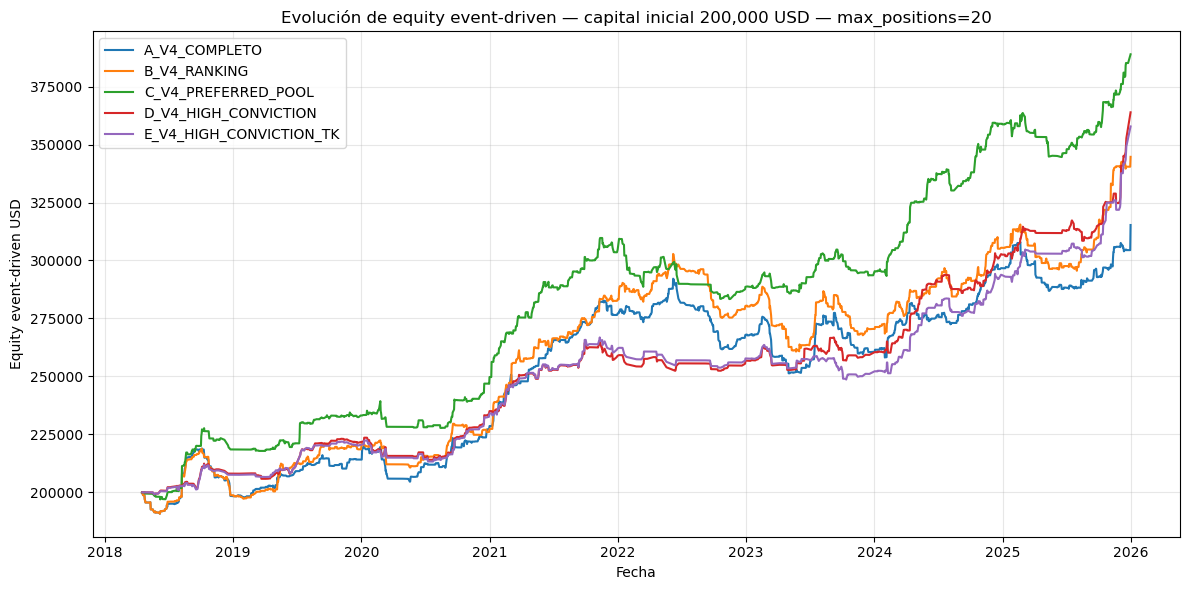

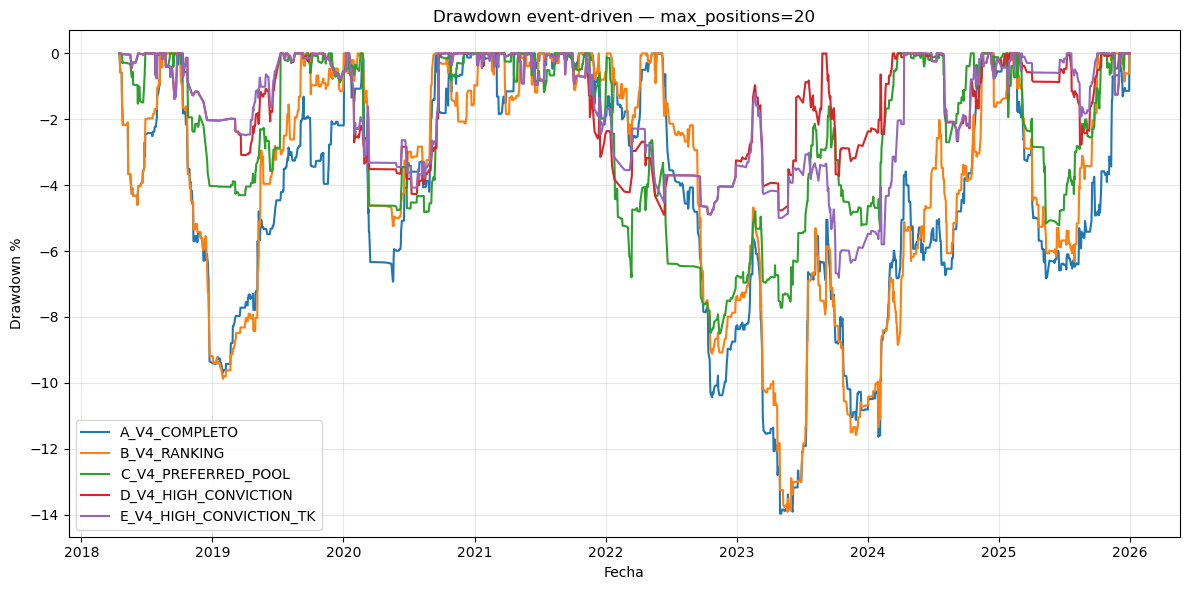

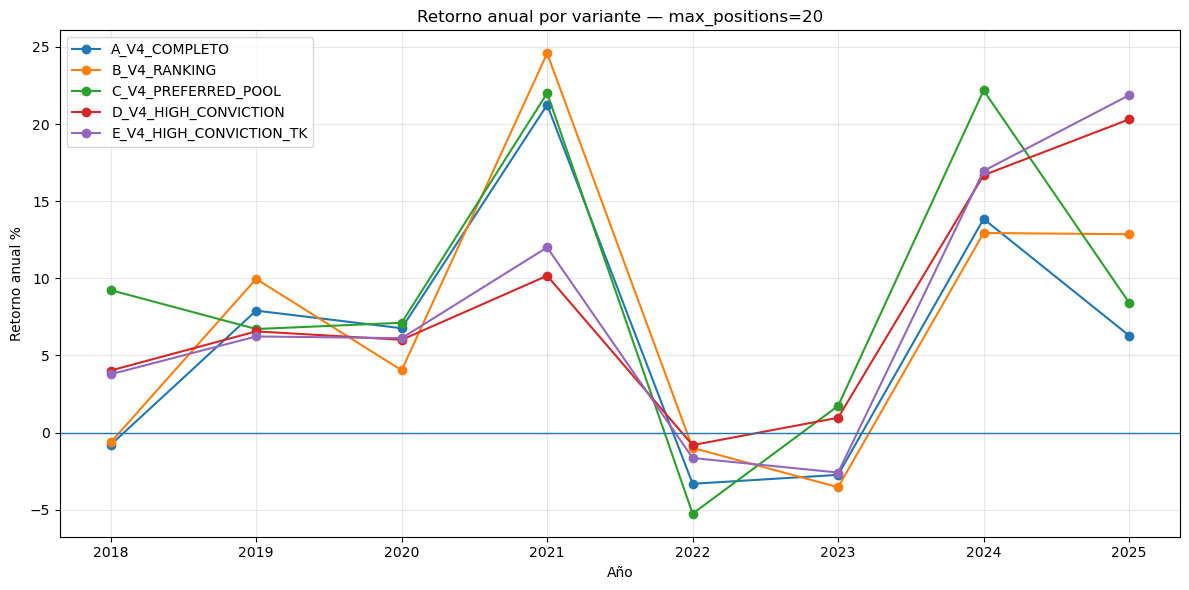

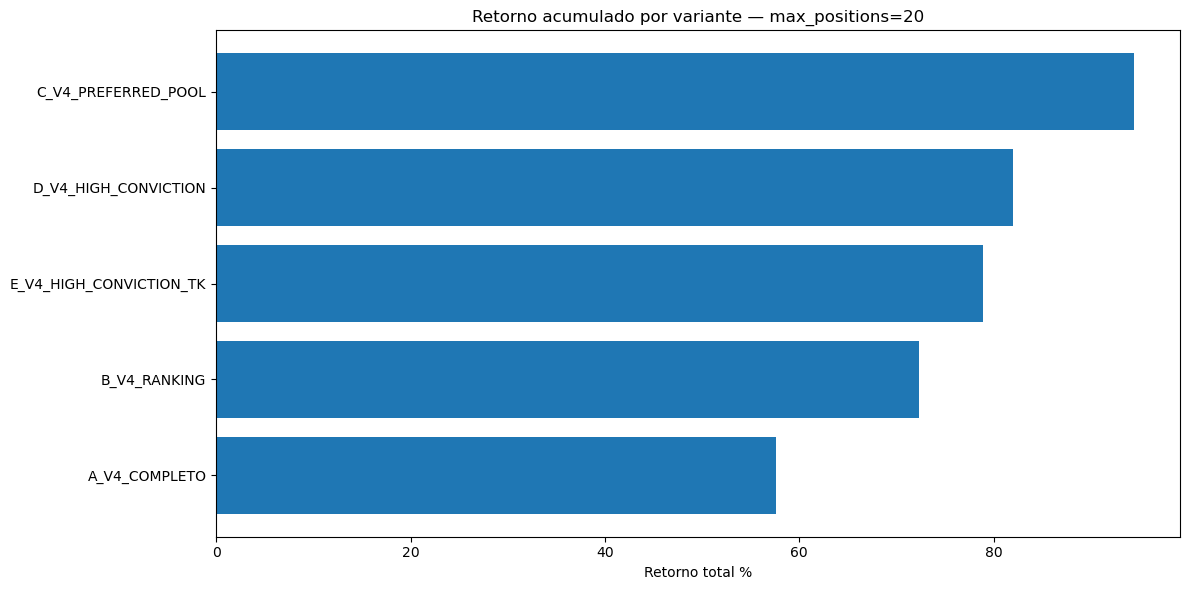

In [10]:
# ============================================================
# 9. Gráficos principales
# ============================================================

base_eq = equity_all[equity_all['max_positions'] == BASE_MAX_POSITIONS].copy()
base_eq = base_eq.sort_values(['variant','date'])

plt.figure(figsize=(12, 6))
for variant, g in base_eq.groupby('variant'):
    plt.plot(g['date'], g['equity_event'], label=variant)
plt.title(f'Evolución de equity event-driven — capital inicial {INITIAL_CAPITAL:,.0f} USD — max_positions={BASE_MAX_POSITIONS}')
plt.xlabel('Fecha')
plt.ylabel('Equity event-driven USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for variant, g in base_eq.groupby('variant'):
    plt.plot(g['date'], g['drawdown'] * 100, label=variant)
plt.title(f'Drawdown event-driven — max_positions={BASE_MAX_POSITIONS}')
plt.xlabel('Fecha')
plt.ylabel('Drawdown %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for variant, g in annual_base.groupby('variant'):
    g = g.sort_values('Year')
    plt.plot(g['Year'], g['return_year_pct'], marker='o', label=variant)
plt.axhline(0, linewidth=1)
plt.title(f'Retorno anual por variante — max_positions={BASE_MAX_POSITIONS}')
plt.xlabel('Año')
plt.ylabel('Retorno anual %')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
summary_base_plot = summary_base.sort_values('return_total_pct', ascending=True)
plt.barh(summary_base_plot['variant'], summary_base_plot['return_total_pct'])
plt.title(f'Retorno acumulado por variante — max_positions={BASE_MAX_POSITIONS}')
plt.xlabel('Retorno total %')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 10. Exportación de resultados
# ============================================================

summary.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_portfolio_global.csv', index=False)
summary_base.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_portfolio_base_maxpos.csv', index=False)
annual.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_portfolio_by_year.csv', index=False)
annual_base.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_portfolio_by_year_base.csv', index=False)
equity_all.to_csv(OUTPUT_DIR / 'df_nb04c_v4_portfolio_equity_curve.csv', index=False)
trades_all.to_csv(OUTPUT_DIR / 'df_nb04c_v4_portfolio_trades.csv', index=False)
actions_all.to_csv(OUTPUT_DIR / 'df_nb04c_v4_portfolio_actions.csv', index=False)
skipped_all.to_csv(OUTPUT_DIR / 'df_nb04c_v4_portfolio_skipped_signals.csv', index=False)
skipped_summary.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_skipped_signals.csv', index=False)
concentration.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_ticker_concentration.csv', index=False)
variant_defs_df.to_csv(OUTPUT_DIR / 'summary_nb04c_v4_variant_definitions.csv', index=False)

summary_json = {
    'run_timestamp': RUN_TIMESTAMP,
    'initial_capital': INITIAL_CAPITAL,
    'cost_bps': COST_BPS,
    'slippage_bps': SLIPPAGE_BPS,
    'base_max_positions': BASE_MAX_POSITIONS,
    'max_positions_grid': MAX_POSITIONS_GRID,
    'input_file': str(trade_audit_path),
    'n_input_signals': int(len(df)),
    'n_input_tickers': int(df['Ticker'].nunique()),
    'kumo_thickness_quantiles': {'q50': float(q50_kumo), 'q60': float(q60_kumo), 'q75': float(q75_kumo)},
    'best_base_variant': summary_base.iloc[0].to_dict(),
    'files': {p.name: str(p.resolve()) for p in OUTPUT_DIR.glob('*')},
}

with open(OUTPUT_DIR / 'summary_nb04c_v4_portfolio.json', 'w', encoding='utf-8') as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2, default=str)

print('Archivos exportados:')
for p in sorted(OUTPUT_DIR.glob('*')):
    print('-', p)

Archivos exportados:
- outputs_nb04c_portfolio_v4_pre_finbert/conclusiones_auto_nb04c_v4_pre_finbert.md
- outputs_nb04c_portfolio_v4_pre_finbert/df_nb04c_v4_portfolio_actions.csv
- outputs_nb04c_portfolio_v4_pre_finbert/df_nb04c_v4_portfolio_equity_curve.csv
- outputs_nb04c_portfolio_v4_pre_finbert/df_nb04c_v4_portfolio_skipped_signals.csv
- outputs_nb04c_portfolio_v4_pre_finbert/df_nb04c_v4_portfolio_trades.csv
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_portfolio.json
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_portfolio_base_maxpos.csv
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_portfolio_by_year.csv
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_portfolio_by_year_base.csv
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_portfolio_global.csv
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_skipped_signals.csv
- outputs_nb04c_portfolio_v4_pre_finbert/summary_nb04c_v4_ticker_concentration.csv
- outputs_nb04c_portfo

In [12]:
# ============================================================
# 11. Conclusiones automáticas para incorporar al análisis humano
# ============================================================

best = summary_base.iloc[0]
base_complete = summary_base[summary_base['variant'] == 'A_V4_COMPLETO'].iloc[0]
base_ranking = summary_base[summary_base['variant'] == 'B_V4_RANKING'].iloc[0]

lines = []
lines.append('# Conclusiones automáticas NB-04C V4 pre-FinBERT')
lines.append('')
lines.append('## 1. Alcance')
lines.append(f'Se simuló una cartera técnica pura con capital inicial de **{INITIAL_CAPITAL:,.0f} USD**, usando las señales V4 auditadas en NB-04B2 y la gestión Core50/Táctico50.')
lines.append('Este resultado todavía **no incorpora FinBERT ni XGBoost**.')
lines.append('')
lines.append('## 2. Resultado base')
lines.append(f'Para el caso base de **{BASE_MAX_POSITIONS} posiciones máximas**, la mejor variante fue **{best["variant"]}**.')
lines.append(f'- Capital final: **{best["capital_final"]:,.2f} USD**')
lines.append(f'- Ganancia/Pérdida acumulada: **{best["pnl_usd"]:,.2f} USD**')
lines.append(f'- Retorno acumulado: **{best["return_total_pct"]:.2f}%**')
lines.append(f'- CAGR: **{best["cagr_pct"]:.2f}%**')
lines.append(f'- Max drawdown event-driven: **{best["max_drawdown_pct"]:.2f}%**')
lines.append(f'- Operaciones ejecutadas: **{int(best["n_trades"]):,}**')
lines.append(f'- Win rate: **{best["win_rate_pct"]:.2f}%**')
lines.append(f'- Profit factor: **{best["profit_factor"]:.2f}**')
lines.append('')
lines.append('## 3. Comparación contra V4 completo')
lines.append(f'La variante A_V4_COMPLETO alcanzó un capital final de **{base_complete["capital_final"]:,.2f} USD**, equivalente a **{base_complete["return_total_pct"]:.2f}%** acumulado.')
lines.append(f'La variante B_V4_RANKING alcanzó un capital final de **{base_ranking["capital_final"]:,.2f} USD**, equivalente a **{base_ranking["return_total_pct"]:.2f}%** acumulado.')
lines.append('La comparación permite evaluar si la priorización interna de señales agrega valor respecto de usar el screener completo sin ranking.')
lines.append('')
lines.append('## 4. Lectura metodológica')
lines.append('El 04C confirma que el problema no es solamente generar señales válidas, sino convertirlas en decisiones de cartera con capital finito. Las variantes más selectivas pueden mejorar el perfil riesgo-retorno aunque ejecuten menos operaciones.')
lines.append('')
lines.append('## 5. Siguiente paso')
lines.append('El siguiente bloque experimental debe incorporar FinBERT como capa contextual/veto, utilizando los años débiles —especialmente 2022— como caso crítico para comprobar si el contexto informativo reduce señales técnicamente válidas pero vulnerables.')

conclusion_text = '\n'.join(lines)
print(conclusion_text)

with open(OUTPUT_DIR / 'conclusiones_auto_nb04c_v4_pre_finbert.md', 'w', encoding='utf-8') as f:
    f.write(conclusion_text)

# Conclusiones automáticas NB-04C V4 pre-FinBERT

## 1. Alcance
Se simuló una cartera técnica pura con capital inicial de **200,000 USD**, usando las señales V4 auditadas en NB-04B2 y la gestión Core50/Táctico50.
Este resultado todavía **no incorpora FinBERT ni XGBoost**.

## 2. Resultado base
Para el caso base de **20 posiciones máximas**, la mejor variante fue **C_V4_PREFERRED_POOL**.
- Capital final: **388,943.19 USD**
- Ganancia/Pérdida acumulada: **188,943.19 USD**
- Retorno acumulado: **94.47%**
- CAGR: **9.01%**
- Max drawdown event-driven: **-8.51%**
- Operaciones ejecutadas: **582**
- Win rate: **54.47%**
- Profit factor: **1.73**

## 3. Comparación contra V4 completo
La variante A_V4_COMPLETO alcanzó un capital final de **315,294.68 USD**, equivalente a **57.65%** acumulado.
La variante B_V4_RANKING alcanzó un capital final de **344,703.04 USD**, equivalente a **72.35%** acumulado.
La comparación permite evaluar si la priorización interna de señales agrega valor respecto de u

## 12. Decisión posterior al notebook

Después de ejecutar este notebook, la decisión metodológica tomada es:

1. Revisar si la mejor variante técnica es estable en retorno, drawdown, exposición y concentración por ticker.
2. No declarar aún superioridad final frente al mercado hasta comparar contra benchmarks pasivos y contra el módulo FinBERT/XGBoost.
3. Usar los resultados anteriores validados como baseline técnico de cartera para el estudio de ablación:
   - técnico puro,
   - técnico + veto,
   - técnico + FinBERT,
   - técnico + FinBERT + XGBoost.


# 12. Análisis  pre-FinBERT

## 12.1. Alcance y lectura metodológica

Este notebook simula una **cartera técnica pura pre-FinBERT** a partir de las señales V4 auditadas en NB-04B2. El capital inicial es de **200.000 USD**, se aplican **10 bps de coste** y **5 bps de slippage**, y el caso base utiliza **20 posiciones simultáneas máximas**. El universo de entrada contiene **8.155 señales** procedentes de **502 tickers**. La simulación todavía **no incorpora FinBERT ni XGBoost**.

Aqu no se evalúa señales aisladas, sino la conversión del screener en una cartera con capital finito, restricciones de simultaneidad, costes, slippage y reglas de ejecución. Por eso los resultados no son directamente comparables con el retorno medio de señal anterior y aquí se ven problemas reales de asignación de capital, saturación de cartera, señales solapadas y cash disponible.


## 12.2. Resultado base con 20 posiciones máximas

| Variante                | Capital final USD   | PnL USD   |   Retorno % |   CAGR % |   Max DD % |   Trades |   Win % |   PF |   Ret. medio trade % |   Exposición coste % |   Pos. abiertas media |
|:------------------------|:--------------------|:----------|------------:|---------:|-----------:|---------:|--------:|-----:|---------------------:|---------------------:|----------------------:|
| C_V4_PREFERRED_POOL     | 388,943             | 188,943   |       94.47 |     9.01 |      -8.51 |      582 |   54.47 | 1.73 |                 2.48 |                61.04 |                 16.71 |
| D_V4_HIGH_CONVICTION    | 363,917             | 163,917   |       81.96 |     8.08 |      -4.91 |      427 |   53.86 | 1.93 |                 2.99 |                49.97 |                 13.69 |
| E_V4_HIGH_CONVICTION_TK | 357,820             | 157,820   |       78.91 |     7.84 |      -6.81 |      410 |   55.37 | 1.97 |                 3.04 |                49.04 |                 13.43 |
| B_V4_RANKING            | 344,703             | 144,703   |       72.35 |     7.32 |     -13.92 |      785 |   48.41 | 1.42 |                 1.54 |                71.72 |                 19.15 |
| A_V4_COMPLETO           | 315,295             | 115,295   |       57.65 |     6.08 |     -13.97 |      787 |   48.79 | 1.36 |                 1.29 |                71.53 |                 19.13 |

**Conclusión:** con 20 posiciones máximas, la mejor variante por capital final es **C_V4_PREFERRED_POOL**, con capital final de **388.943 USD**, ganancia acumulada de **188.943 USD**, retorno total de **94,47%**, CAGR de **9,01%** y drawdown event-driven de **-8,51%**. La variante **D_V4_HIGH_CONVICTION** gana menos en retorno absoluto, pero presenta el mejor perfil defensivo por drawdown (**-4,91%**) y un profit factor alto (**1,93**). La variante **E_V4_HIGH_CONVICTION_TK** mejora el win rate y el profit factor frente a D, pero con mayor drawdown y menor retorno acumulado.

## 12.3. Sensibilidad a número máximo de posiciones

| Variante                |   Max posiciones | Capital final USD   |   Retorno % |   CAGR % |   Max DD % |   Trades |   PF |
|:------------------------|-----------------:|:--------------------|------------:|---------:|-----------:|---------:|-----:|
| C_V4_PREFERRED_POOL     |               10 | 517,811             |      158.91 |    13.13 |     -11.2  |      321 | 2.02 |
| D_V4_HIGH_CONVICTION    |               10 | 452,097             |      126.05 |    11.16 |     -12.71 |      263 | 2.03 |
| E_V4_HIGH_CONVICTION_TK |               10 | 429,078             |      114.54 |    10.41 |     -11.49 |      254 | 2    |
| C_V4_PREFERRED_POOL     |               20 | 388,943             |       94.47 |     9.01 |      -8.51 |      582 | 1.73 |
| D_V4_HIGH_CONVICTION    |               20 | 363,917             |       81.96 |     8.08 |      -4.91 |      427 | 1.93 |

**Lectura:** dentro del grid 10/20/30 posiciones, la variante **C_V4_PREFERRED_POOL con 10 posiciones** alcanza el mayor capital final global (**517.811 USD**) y CAGR (**13,13%**), aunque con mayor concentración y drawdown que C con 20 posiciones. Para el TFM, el caso de 20 posiciones sigue siendo una referencia más equilibrada para evitar que el resultado dependa demasiado de pocas posiciones simultáneas. No obstante, el resultado sugiere que el número máximo de posiciones debe tratarse como un parámetro operativo relevante y no como un detalle menor.

## 12.4. Retorno anual por variante base

|   Año |   A completo % |   B ranking % |   C preferred % |   D high conviction % |   E high conviction TK % |
|------:|---------------:|--------------:|----------------:|----------------------:|-------------------------:|
|  2018 |          -0.8  |         -0.64 |            9.23 |                  4.02 |                     3.78 |
|  2019 |           7.9  |          9.96 |            6.71 |                  6.56 |                     6.23 |
|  2020 |           6.76 |          4.04 |            7.12 |                  6.01 |                     6.12 |
|  2021 |          21.24 |         24.58 |           22    |                 10.16 |                    12    |
|  2022 |          -3.32 |         -1    |           -5.26 |                 -0.81 |                    -1.65 |
|  2023 |          -2.74 |         -3.54 |            1.73 |                  0.96 |                    -2.59 |
|  2024 |          13.85 |         12.94 |           22.18 |                 16.68 |                    16.96 |
|  2025 |           6.29 |         12.86 |            8.42 |                 20.3  |                    21.87 |

**Lectura de régimen:** 2022 sigue siendo el año crítico para el sistema técnico. La variante C, aunque es la mejor en retorno acumulado, sufre en 2022 (**-5,26%**). En cambio, las variantes high conviction reducen mucho el daño: **D pierde solo -0,81%** y **E pierde -1,65%**. Esto refuerza la hipótesis de que el problema no es únicamente la validez técnica de la señal, sino la necesidad de seleccionar mejor qué señales ejecutar bajo regímenes adversos. 2022 debe usarse como caso crítico para evaluar si FinBERT y los vetos contextuales reducen entradas técnicamente válidas pero vulnerables.

## 12.5. Calidad de los pools antes de convertirlos en cartera

| Variante                |   Señales elegibles |   Tickers |   Ret. medio señal % |   Ret. mediano señal % |   Win señal % |   MFE medio % |   MAE medio % |
|:------------------------|--------------------:|----------:|---------------------:|-----------------------:|--------------:|--------------:|--------------:|
| A_V4_COMPLETO           |                8155 |       502 |                 1.53 |                  -0    |         49.98 |         12.83 |         -6.34 |
| B_V4_RANKING            |                8155 |       502 |                 1.53 |                  -0    |         49.98 |         12.83 |         -6.34 |
| C_V4_PREFERRED_POOL     |                1960 |       465 |                 2.71 |                   0.73 |         52.96 |         15.86 |         -6.98 |
| D_V4_HIGH_CONVICTION    |                 713 |       331 |                 4.04 |                   1.6  |         57.22 |         18.78 |         -7.03 |
| E_V4_HIGH_CONVICTION_TK |                 659 |       316 |                 3.96 |                   1.6  |         57.66 |         18.7  |         -7.11 |

**Lectura:** el filtrado progresivo mejora claramente la calidad media de señal. El universo completo A/B tiene retorno medio individual de señal cercano a **1,53%** y win rate de **49,98%**. El pool C sube a **2,71%** de retorno medio y **52,96%** de win rate. El high conviction D/E supera el **4%** de retorno medio de señal y el **57%** de win rate. Esto explica por qué las variantes selectivas mejoran el perfil de cartera aunque ejecuten menos operaciones.

## 12.6. Señales no ejecutadas y saturación de cartera

| Variante                |   Insufficient Cash |   Max Positions |   Ticker Already Open |
|:------------------------|--------------------:|----------------:|----------------------:|
| A_V4_COMPLETO           |                   0 |            6738 |                   630 |
| B_V4_RANKING            |                   0 |            6728 |                   642 |
| C_V4_PREFERRED_POOL     |                  28 |            1141 |                   209 |
| D_V4_HIGH_CONVICTION    |                   8 |             214 |                    64 |
| E_V4_HIGH_CONVICTION_TK |                   7 |             184 |                    58 |

**Lectura:** en A y B se descartan miles de señales por saturación de posiciones máximas. Esto confirma que el screener produce más oportunidades que capacidad real de ejecución. Por eso el ranking y la selección previa no son accesorios: son necesarios para decidir qué señales entran cuando el capital es finito. En C, D y E la cantidad de señales saltadas cae de forma marcada, lo que muestra que la selección previa reduce ruido operativo y evita competir por capital entre señales de baja prioridad.

## 12.7. Conclusión 

El 04C confirma tres hallazgos:

1. **El contrato técnico V4 sí es operable como cartera**, no solo como métrica de señal aislada. Todas las variantes base terminan con capital final superior a 200.000 USD.
2. **La priorización agrega valor**: C, D y E superan a A y B en retorno/riesgo, lo que confirma que no conviene pasar todas las señales V4 a cartera sin filtrado.
3. **El régimen importa**: 2022 y parcialmente 2023 muestran que una señal técnicamente correcta puede fallar en contextos adversos. Esta evidencia justifica la siguiente fase híbrida con FinBERT como capa contextual/veto y, posteriormente, XGBoost como meta-validador.
